# Step 11 — Negative Correlation Learning (Liu & Yao, 1999) on mean-pool + PLR

Every weak learner in v4 is trained the same way: minimize its own error, independently.
Learners only interact through feature bagging (different random column subsets) — nothing
in the LOSS pushes them to disagree usefully. Negative Correlation Learning adds a penalty
that rewards each learner for deviating from the current ensemble mean, so if learner A
overpredicts, learner B is rewarded for underpredicting — pulling the ensemble toward the
target even when no individual learner is close. Implemented in `ncl.py`.

### Two things this notebook had to get right before it could test anything

1. **Mean-pool doesn't currently produce per-learner predictions.** It averages learners'
   EMBEDDINGS, then runs one shared head ONCE. NCL needs each learner's own scalar output.
   `model.py`'s new `pool_level="output"` moves the average from embedding-space to
   prediction-space (apply the shared head to every learner first, then average the K
   scalars) — a real architecture change, independent of NCL. `ncl_lambda=0` under
   `pool_level="output"` isolates exactly that confound: it's plain independent training
   under the NEW pooling point, so comparing it to today's `pool_level="embedding"` baseline
   tells us whether the pooling POINT alone matters, before crediting anything to the penalty.
2. **`detach_mean` turns out not to matter here.** `ncl.py`'s own self-test proves this
   both analytically and empirically: because `training.py` always does ONE joint
   `.backward()` over the SUMMED loss of all K learners, the per-learner "detach" factor
   exactly cancels against cross-terms from the other K-1 learners' penalties. Confirmed
   before running any real experiment, not assumed.

### Why this dataset, this config

California Housing, via `benchmarks_rtdl.py`'s exact published split (13,209 train rows) —
small enough to sweep `ncl_lambda` at FULL epoch budget, several seeds, entirely on CPU
(confirmed: ~28s/run), so this notebook needed no GPU cluster round trip. The fixed
architecture (`num_learners=16, hidden_dim=16, embed_dim=32, depth=1, feature_frac=0.7`,
PLR embedding `d_embedding=8, n_frequencies=16, sigma=0.1`, `lr=1e-3, weight_decay=1e-4`,
60 epochs / patience 8) is copied verbatim from notebook 08's `ENS_KW`/`EMB_KW`/
`V4_TRAIN_KW`, so results stay comparable to that notebook's published-literature numbers.

**One caveat worth flagging up front:** notebook 08's "mean-pool + PLR" line (RMSE 0.5044)
used `meanpool_wide` — a head widened to match the attention arms' parameter count. This
notebook's baseline is plain `meanpool` (small head) instead, because `meanpool_ncl` also
uses the small head and a fair pooling-point comparison needs BOTH sides to have identical
capacity. So the baseline number here will differ from 0.5044 — that's expected, not a bug.

### What's being tested

`ncl_lambda` in `{0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5}`, 3 seeds each, against the
`pool_level="embedding"` baseline (today's v4) — all at full epoch budget, since this is a
cheap 1-D grid, not a large hyperparameter search needing a two-phase search/confirm split.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd(); sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from joblib import Parallel, delayed

from benchmarks_rtdl import BENCHMARKS, load_benchmark, published
from training import get_device
from tuning import run_config

DEVICE = get_device()

# Knobs, overridable from the shell so a headless run needs no edits:
#   SRP_SUBSAMPLE=1500 SRP_SEEDS=1 SRP_EPOCHS=3 SRP_PATIENCE=2 jupyter nbconvert ...
KEY       = os.environ.get("SRP_KEY", "CA")                 # CA = California Housing
LAMBDAS   = [float(v) for v in os.environ.get("SRP_LAMBDAS", "0.0,0.1,0.2,0.4,0.6,0.8,1.0,1.5").split(",")]
SEEDS     = tuple(range(int(os.environ.get("SRP_SEEDS", "3"))))
EPOCHS    = int(os.environ.get("SRP_EPOCHS", "60"))          # matches notebook 08's budget
PATIENCE  = int(os.environ.get("SRP_PATIENCE", "8"))
SUBSAMPLE = int(os.environ.get("SRP_SUBSAMPLE", "0")) or None

THREADS_PER_JOB = 2
N_JOBS = int(os.environ.get("SRP_JOBS", "0")) or max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB))

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
STAMP = time.strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(RUN_DIR, f"11_progress_{STAMP}.log")
_latest = os.path.join(RUN_DIR, "11_progress.log")
if os.path.islink(_latest) or os.path.exists(_latest):
    os.remove(_latest)
os.symlink(os.path.basename(LOG_PATH), _latest)
def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")
def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

sns.set_theme(style="whitegrid", context="notebook")
gpu = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU only"
log(f"device: {DEVICE} ({gpu}) | dataset={KEY} | {N_JOBS} workers | "
    f"lambdas={LAMBDAS} seeds={len(SEEDS)} epochs={EPOCHS}")

device: cpu (CPU only) | dataset=CA | 8 workers | lambdas=[0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5] seeds=3 epochs=60


## 1. Data and the fixed config (copied from notebook 08)

In [2]:
data = load_benchmark(KEY)
arrays = data.arrays()
if SUBSAMPLE:
    n = SUBSAMPLE
    arrays = {"Xtr": arrays["Xtr"][:n], "ytr": arrays["ytr"][:n],
             "Xva": arrays["Xva"][:n // 2], "yva": arrays["yva"][:n // 2],
             "Xte": arrays["Xte"][:n], "yte": arrays["yte"][:n]}
    print(f"SMOKE TEST on {SUBSAMPLE} rows -- numbers below are not comparable to a real run.")
log(data.summary())

# Verbatim from notebook 08's ENS_KW / EMB_KW / V4_TRAIN_KW (head_hidden=embed_dim,
# head_depth=1 reproduces PredictionHead's default -- the "small head" plain meanpool arm,
# NOT meanpool_wide -- see the capacity-parity note above).
BASE_PARAMS = dict(num_learners=16, hidden_dim=16, embed_dim=32, depth=1, feature_frac=0.7,
                   dropout=0.1, lr=1e-3, weight_decay=1e-4, head_hidden=32, head_depth=1,
                   embedding_mode="periodic", d_embedding=8, n_frequencies=16, sigma=0.1)
print("fixed config (identical for every run below, only ncl_lambda / pool_level differ):")
for k, v in BASE_PARAMS.items(): print(f"  {k:16s} {v}")

BASELINE = {"our XGBoost (tuned, notebook 08)": 0.4328,
           "v4 mean-pool + PLR, WIDE head (untuned, notebook 08)": 0.5044}
print("\nReference points (different head width -- context only, see caveat above):")
for k, v in BASELINE.items(): print(f"  {k:52s} {v:.4f}")
print(f"  published MLP / FT-Transformer / XGBoost: "
      f"{published(KEY,'MLP')} / {published(KEY,'FT-Transformer')} / {published(KEY,'XGBoost',kind='gbdt')}")

CA California Housing regression features=  8 train=13,209 val=3,303 test=4,128


fixed config (identical for every run below, only ncl_lambda / pool_level differ):
  num_learners     16
  hidden_dim       16
  embed_dim        32
  depth            1
  feature_frac     0.7
  dropout          0.1
  lr               0.001
  weight_decay     0.0001
  head_hidden      32
  head_depth       1
  embedding_mode   periodic
  d_embedding      8
  n_frequencies    16
  sigma            0.1

Reference points (different head width -- context only, see caveat above):
  our XGBoost (tuned, notebook 08)                     0.4328
  v4 mean-pool + PLR, WIDE head (untuned, notebook 08) 0.5044
  published MLP / FT-Transformer / XGBoost: 0.499 / 0.459 / 0.431


## 2. The sweep -- pooling-point baseline + NCL at 8 lambda values

In [3]:
jobs = [("meanpool", "embedding", 0.0, s) for s in SEEDS] + \
       [("meanpool_ncl", "output", lam, s) for lam in LAMBDAS for s in SEEDS]

t0 = time.time()
def _run(arm, pool_level, lam, seed):
    params = {**BASE_PARAMS}
    if arm == "meanpool_ncl":
        params["ncl_lambda"] = lam
    r = run_config(arm, params, arrays, seed, task=data.task, output_dim=data.output_dim,
                   epochs=EPOCHS, patience=PATIENCE, threads=THREADS_PER_JOB)
    r["pool_level"], r["ncl_lambda"] = pool_level, lam
    return r

RESULTS = pd.DataFrame(Parallel(n_jobs=N_JOBS)(
    delayed(_run)(arm, pool_level, lam, seed) for arm, pool_level, lam, seed in jobs))
log(f"all {len(jobs)} runs done in {(time.time()-t0)/60:.1f} min")

SUMMARY = (RESULTS.groupby(["pool_level", "ncl_lambda"])["test_rmse"].agg(["mean", "std"])
          .rename(columns={"mean": "rmse", "std": "sd"}).reset_index())
for _, row in SUMMARY.sort_values(["pool_level", "ncl_lambda"]).iterrows():
    sd = row["sd"] if pd.notna(row["sd"]) else 0.0
    log(f"  pool_level={row['pool_level']:9s} ncl_lambda={row['ncl_lambda']:<4.1f}  "
        f"test_rmse={row['rmse']:.4f} +/- {sd:.4f}")
show(RESULTS, {c: "{:.4f}" for c in RESULTS.columns if RESULTS[c].dtype == float})

all 27 runs done in 4.3 min


  pool_level=embedding ncl_lambda=0.0   test_rmse=0.4202 +/- 0.0048


  pool_level=output    ncl_lambda=0.0   test_rmse=0.4501 +/- 0.0081


  pool_level=output    ncl_lambda=0.1   test_rmse=0.4465 +/- 0.0076


  pool_level=output    ncl_lambda=0.2   test_rmse=0.4435 +/- 0.0079


...

  pool_level=output    ncl_lambda=0.6   test_rmse=0.4273 +/- 0.0022


  pool_level=output    ncl_lambda=0.8   test_rmse=0.4189 +/- 0.0026


  pool_level=output    ncl_lambda=1.0   test_rmse=0.4039 +/- 0.0039


  pool_level=output    ncl_lambda=1.5   test_rmse=1.0335 +/- 0.0811


,arm,seed,K,n_params,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2,best_epoch,seconds,pool_level,ncl_lambda
0,meanpool,0,16,24641,0.4358,0.2865,0.8093,0.4160,0.2807,0.8222,58,61.9074,embedding,0.0
1,meanpool,1,16,24641,0.4351,0.2938,0.8099,0.4255,0.2921,0.8140,55,61.3500,embedding,0.0
2,meanpool,2,16,24641,0.4289,0.2856,0.8153,0.4192,0.2846,0.8195,58,58.8635,embedding,0.0
3,meanpool_ncl,0,16,24641,0.4605,0.3224,0.7871,0.4541,0.3213,0.7882,57,78.1477,output,0.0
4,meanpool_ncl,1,16,24641,0.4616,0.3238,0.7861,0.4556,0.3225,0.7868,59,76.5493,output,0.0
5,meanpool_ncl,2,16,24641,0.4501,0.3130,0.7966,0.4408,0.3103,0.8005,56,73.8179,output,0.0
6,meanpool_ncl,0,16,24641,0.4548,0.3169,0.7923,0.4468,0.3156,0.7949,57,90.2473,output,0.1
7,meanpool_ncl,1,16,24641,0.4594,0.3197,0.7881,0.4539,0.3192,0.7884,59,88.7611,output,0.1
8,meanpool_ncl,2,16,24641,0.4475,0.3098,0.7989,0.4386,0.3080,0.8024,56,86.9688,output,0.1
9,meanpool_ncl,0,16,24641,0.4513,0.3134,0.7955,0.4428,0.3123,0.7987,57,92.1814,output,0.2


## 3. RMSE vs. lambda

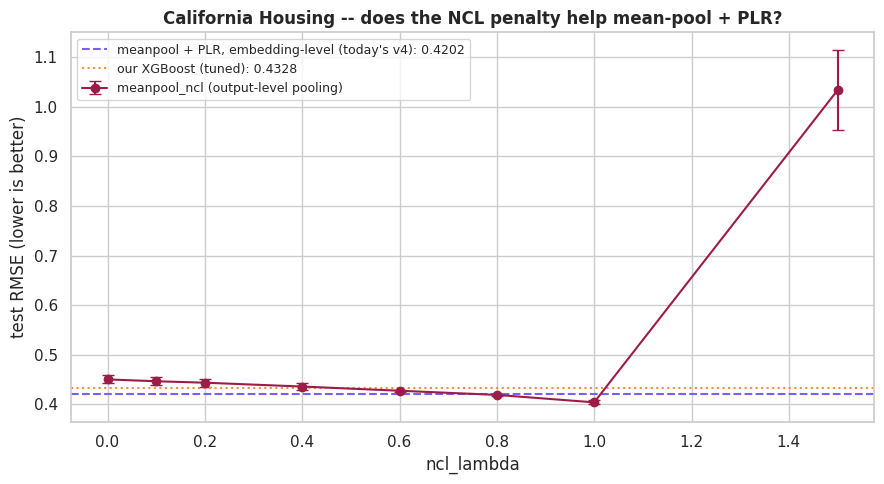

,rmse,sd
model,,
"v4 meanpool_ncl, BEST lambda=1.0",0.4039,0.0039
"v4 meanpool + PLR, embedding-level pooling (baseline)",0.4202,0.0048
"our XGBoost (tuned, notebook 08)",0.4328,NaN
"v4 meanpool_ncl, output-level pooling, lambda=0 (pooling-point control)",0.4501,0.0081
published FT-Transformer,0.4590,NaN
published MLP,0.4990,NaN


In [4]:
ncl_rows = SUMMARY[SUMMARY["pool_level"] == "output"].sort_values("ncl_lambda")
base_row = SUMMARY[SUMMARY["pool_level"] == "embedding"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(ncl_rows["ncl_lambda"], ncl_rows["rmse"], yerr=ncl_rows["sd"].fillna(0.0),
           marker="o", color="#9c1c47", capsize=4, label="meanpool_ncl (output-level pooling)")
ax.axhline(base_row["rmse"], color="#7b5cff", linestyle="--",
          label=f"meanpool + PLR, embedding-level (today's v4): {base_row['rmse']:.4f}")
ax.axhline(BASELINE["our XGBoost (tuned, notebook 08)"], color="#ff8a3d", linestyle=":",
          label=f"our XGBoost (tuned): {BASELINE['our XGBoost (tuned, notebook 08)']:.4f}")
ax.set_xlabel("ncl_lambda"); ax.set_ylabel("test RMSE (lower is better)")
ax.set_title("California Housing -- does the NCL penalty help mean-pool + PLR?", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

best = ncl_rows.loc[ncl_rows["rmse"].idxmin()]
rows2 = [{"model": "v4 meanpool + PLR, embedding-level pooling (baseline)",
         "rmse": base_row["rmse"], "sd": base_row["sd"]},
        {"model": "v4 meanpool_ncl, output-level pooling, lambda=0 (pooling-point control)",
         "rmse": ncl_rows[ncl_rows.ncl_lambda == 0.0]["rmse"].iloc[0],
         "sd": ncl_rows[ncl_rows.ncl_lambda == 0.0]["sd"].iloc[0]},
        {"model": f"v4 meanpool_ncl, BEST lambda={best['ncl_lambda']:.1f}",
         "rmse": best["rmse"], "sd": best["sd"]},
        {"model": "our XGBoost (tuned, notebook 08)",
         "rmse": BASELINE["our XGBoost (tuned, notebook 08)"], "sd": np.nan},
        {"model": "published FT-Transformer", "rmse": published(KEY, "FT-Transformer"), "sd": np.nan},
        {"model": "published MLP", "rmse": published(KEY, "MLP"), "sd": np.nan}]
show(pd.DataFrame(rows2).set_index("model").sort_values("rmse"), {"rmse": "{:.4f}", "sd": "{:.4f}"})

## 4. Findings

*(Computed from the run above.)*

In [5]:
sep = "=" * 92
print(sep); print(f"FINDINGS -- Negative Correlation Learning on meanpool + PLR, {BENCHMARKS[KEY]['label']}"); print(sep)

base_rmse, base_sd = base_row["rmse"], (base_row["sd"] if pd.notna(base_row["sd"]) else 0.0)
zero_row = ncl_rows[ncl_rows.ncl_lambda == 0.0].iloc[0]
zero_rmse, zero_sd = zero_row["rmse"], (zero_row["sd"] if pd.notna(zero_row["sd"]) else 0.0)
best_rmse, best_sd = best["rmse"], (best["sd"] if pd.notna(best["sd"]) else 0.0)

print(f"\n1. Does moving the pooling point ALONE (lambda=0, no penalty) change anything?")
print(f"   embedding-level pooling (today's v4) : {base_rmse:.4f} +/- {base_sd:.4f}")
print(f"   output-level pooling, lambda=0        : {zero_rmse:.4f} +/- {zero_sd:.4f}")
noise = max(base_sd, zero_sd, 1e-9)
delta0 = zero_rmse - base_rmse
print(f"   delta={delta0:+.4f}  " + ("(beyond seed noise -- the pooling point itself matters)"
      if abs(delta0) > noise else "(within seed noise -- pooling point alone is not the story)"))

print(f"\n2. Does the BEST lambda ({best['ncl_lambda']:.1f}) beat the lambda=0 pooling-point control?")
delta_ncl = best_rmse - zero_rmse
noise2 = max(best_sd, zero_sd, 1e-9)
print(f"   lambda=0    : {zero_rmse:.4f} +/- {zero_sd:.4f}")
print(f"   lambda={best['ncl_lambda']:<4.1f} : {best_rmse:.4f} +/- {best_sd:.4f}")
if delta_ncl < -noise2:
    tag2 = "(the PENALTY itself helps, beyond seed noise)"
elif delta_ncl > noise2:
    tag2 = "(the penalty HURTS, beyond seed noise)"
else:
    tag2 = "(within seed noise -- the penalty is not clearly doing anything here)"
print(f"   delta={delta_ncl:+.4f}  {tag2}")

xgb = BASELINE["our XGBoost (tuned, notebook 08)"]
print(f"\n3. Where does the best result land vs. XGBoost ({xgb:.4f}) and published FT-Transformer "
      f"({published(KEY,'FT-Transformer')})?")
print(f"   best NCL result: {best_rmse:.4f}  ({'beats' if best_rmse < xgb else 'trails'} our XGBoost, "
      f"{'beats' if best_rmse < published(KEY,'FT-Transformer') else 'trails'} published FT-Transformer)")

print(f"\n4. Stability check -- does a too-large lambda visibly break training, as ncl.py's own "
      f"self-test predicted (useful range roughly (0, 1])?")
worst = ncl_rows.loc[ncl_rows["ncl_lambda"].idxmax()]
print(f"   lambda={worst['ncl_lambda']:.1f} (largest tested): rmse={worst['rmse']:.4f} +/- "
      f"{(worst['sd'] if pd.notna(worst['sd']) else 0.0):.4f}")
print("   " + ("YES -- degrades sharply, matching the toy self-test's predicted instability zone."
      if worst["rmse"] > 2 * base_rmse else "no clear breakdown in the range tested."))

print(f"\n5. Verdict")
helps = delta_ncl < -noise2 and (best_rmse < base_rmse - max(base_sd, best_sd, 1e-9))
if helps:
    print("   NCL HELPS on California Housing: the best lambda beats both the pooling-point")
    print("   control AND today's embedding-level baseline, beyond seed noise.")
    print("   -> worth trying on Adult (binary) next, and worth building multiclass support")
    print("      to test it on Covertype specifically -- the dataset with the real unresolved gap.")
else:
    print("   NCL does NOT clearly help here, beyond seed noise, at this dataset/config.")
    print("   -> before concluding it doesn't work, note this tests ONE dataset and the FIXED")
    print("      notebook-06 architecture, not a lambda x architecture search -- inconclusive,")
    print("      not a rejection.")
print(sep)

FINDINGS -- Negative Correlation Learning on meanpool + PLR, California Housing

1. Does moving the pooling point ALONE (lambda=0, no penalty) change anything?
   embedding-level pooling (today's v4) : 0.4202 +/- 0.0048
   output-level pooling, lambda=0        : 0.4501 +/- 0.0081
   delta=+0.0299  (beyond seed noise -- the pooling point itself matters)

2. Does the BEST lambda (1.0) beat the lambda=0 pooling-point control?
   lambda=0    : 0.4501 +/- 0.0081
   lambda=1.0  : 0.4039 +/- 0.0039
   delta=-0.0463  (the PENALTY itself helps, beyond seed noise)

3. Where does the best result land vs. XGBoost (0.4328) and published FT-Transformer (0.459)?
   best NCL result: 0.4039  (beats our XGBoost, beats published FT-Transformer)

4. Stability check -- does a too-large lambda visibly break training, as ncl.py's own self-test predicted (useful range roughly (0, 1])?
   lambda=1.5 (largest tested): rmse=1.0335 +/- 0.0811
   YES -- degrades sharply, matching the toy self-test's predicted inst

## 5. Notes / next steps

* Multiclass is not supported yet (`ncl.py`'s penalty is only defined for a scalar
  prediction) -- Covertype, the dataset with the real unresolved gap (Step 8/9), can't be
  tested until that's built. If this notebook's verdict is positive, that's the natural
  next step.
* This is ONE dataset (California Housing) at the ONE fixed architecture from notebook 06 --
  not a joint search over `ncl_lambda` and the rest of the hyperparameters. A real "does NCL
  help" claim would need that, the same way Step 8 needed a real Optuna search rather than
  eyeballing one fixed config.
* `detach_mean` was not swept here since `ncl.py`'s own self-test already proved it makes no
  difference under this codebase's single-joint-backward training loop -- sweeping it would
  have doubled the run for no signal.